# openEO parcel-based FAPAR processing workflow

In this notebook, we explore how openEO can use the Terrascope collection to analyse parcel-based FAPAR time series. The workflow includes loading the **Terrascope Sentinel-2 BIOPAR FAPAR** product at 20 m for the NUTS3 region of Tongeren, restricting the raster data to delineated agricultural parcels, and comparing raw and Whittaker-smoothed time series.

In the notebook, we use the delineated parcels from the 2025 and 2026 parcel delineations and run the openEO workflow for Season 1 (1 August 2024 to 31 December 2025) and Season 2 (1 August 2025 to 31 August 2026). 


### In other words,
1. Prepare the Tongeren area of interest and the 2025 and 2026 parcel layers.
2. Load, filter, scale, and sample FAPAR.
3. Export dekadal FAPAR before smoothing as a reference.
4. Apply Whittaker smoothing at the original observation level, then aggregate to dekads.
5. Compare crop-specific FAPAR profiles and export quality layers showing valid observations before and after smoothing.

In [12]:
import json
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

import openeo
from openeo.processes import if_

In the cell below, we read the Tongeren NUTS3 boundary and reproject it to WGS 84 (`EPSG:4326`), the coordinate reference system used by the openEO. This boundary is taken as the area of interest for loading the Terrascope data for this specific region.

In [2]:
Tongeren_polygon = gpd.read_file("NUTS3_Tongeren.gpkg")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")

# load to 4326
Tongeren_polygon = Tongeren_polygon.to_crs("EPSG:4326")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")


type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:3035
type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:4326


In [3]:
# feature collection from geopandas dataframe
aoi = json.loads(Tongeren_polygon.to_json())

Two overlapping windows are defined for the analysis: 
- **Season 1** covers 1 August 2024 to 31 December 2025,
- **Season 2** covers 1 August 2025 to 31 August 2026. 

In [4]:
# Time window:
# - Season 1: August/2024 – Dec/2025 (the focus is the season Oct/2024 – Oct/2025, but it is good to have some data before and after to test the smoothing/gap filling algorithm)
# - Season 2: August/2025 – now (the focus is the season Oct/2025 – NRT)
season1 = ["2024-08-01", "2025-12-31"]
season2 = ["2025-08-01", "2026-08-31"]

In [5]:
connection = openeo.connect("openeo.terrascope.be").authenticate_oidc()

Authenticated using refresh token.



Next, let us load the parcel-delineation files for 2025 and 2026. Parcels provide the agricultural mask and carry `AGPAKEY` for identifying exported results and `MAINCROP` for grouping plots by crop type. Since the number of parcels is large and the aim of the notebook is to test the workflow, we will use the first 100 parcels as an initial, manageable test subset.

In [6]:
# load field from parcel delination
fields_2025 = gpd.read_file("AGRIPRC2025_Tongeren_selection.gpkg")
fields_2025 = fields_2025.to_crs("EPSG:4326")
subset_fields_2025 = fields_2025[:100]
print(f"length of fields_2025: {len(fields_2025)}")

# load field from parcel delination 2026
fields_2026 = gpd.read_file("AGRIPRC2026_Tongeren_selection.gpkg")
fields_2026 = fields_2026.to_crs("EPSG:4326")
subset_fields_2026 = fields_2026[:100]
print(f"length of fields_2026: {len(fields_2026)}")

length of fields_2025: 6780
length of fields_2026: 5951


In [7]:
def delinated_fapar(temporal_extent, fields):
    s2_fapar = connection.load_stac(
        url = "https://stac.terrascope.be/collections/terrascope-s2-fapar-v2",
        spatial_extent = aoi,
        temporal_extent = temporal_extent,
        bands = ["FAPAR"],
        properties = {"gsd":lambda x: x==20}
    )
    scale = 0.005
    offset = 0

    s2_fapar_scaled = s2_fapar.apply(lambda x: x * scale + offset)
    
    delineated_map = s2_fapar_scaled.filter_spatial(json.loads(fields.to_json()))
    return delineated_map  
    

This helper function builds the reusable openEO loading STAC chain for either season. It loads the `terrascope-s2-fapar-v2` STAC collection over Tongeren, selects the `FAPAR` band, and filters the collection to the requested 20 m ground sampling distance.

The product values are scaled by `0.005`, and then `filter_spatial` is used to restrict the cube to the selected parcel geometries, ensuring that subsequent jobs process only the parcels of interest.

## Season 1: August 2024 to December 2025

Before applying Whittaker smoothing, we aggregate the parcel-filtered FAPAR cube to dekads using the mean in the following cell. The idea was to create a product at regular intervals and then export it for reference. 

In [8]:
# aggregate to dekad to check the data before smoothing
delineated_map = delinated_fapar(season1, subset_fields_2025)

without_smoothing = delineated_map.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job_nosmooth = without_smoothing.create_job(
    title="100 fields without smoothing",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job_nosmooth.start_and_wait()


0:00:00 Job 'j-26090614453042cd97c66ec1dfff04cc': send 'start'
0:00:14 Job 'j-26090614453042cd97c66ec1dfff04cc': created (progress 0%)
0:00:19 Job 'j-26090614453042cd97c66ec1dfff04cc': queued (progress 0%)
0:00:25 Job 'j-26090614453042cd97c66ec1dfff04cc': queued (progress 0%)
0:00:33 Job 'j-26090614453042cd97c66ec1dfff04cc': queued (progress 0%)
0:00:43 Job 'j-26090614453042cd97c66ec1dfff04cc': queued (progress 0%)
0:00:56 Job 'j-26090614453042cd97c66ec1dfff04cc': running (progress 6.9%)
0:01:11 Job 'j-26090614453042cd97c66ec1dfff04cc': running (progress 9.0%)
0:01:31 Job 'j-26090614453042cd97c66ec1dfff04cc': running (progress 11.6%)
0:01:55 Job 'j-26090614453042cd97c66ec1dfff04cc': running (progress 14.7%)
0:02:25 Job 'j-26090614453042cd97c66ec1dfff04cc': running (progress 18.2%)
0:03:02 Job 'j-26090614453042cd97c66ec1dfff04cc': running (progress 22.1%)
0:03:49 Job 'j-26090614453042cd97c66ec1dfff04cc': running (progress 26.6%)
0:04:48 Job 'j-26090614453042cd97c66ec1dfff04cc': running 

<BatchJob job_id='j-26090614453042cd97c66ec1dfff04cc'>

In [9]:
result = deked_job_nosmooth.get_results()
result.download_files("original_fapar/")

[WindowsPath('original_fapar/openEO_10260_1152548037.nc'),
 WindowsPath('original_fapar/openEO_10260_1152550158.nc'),
 WindowsPath('original_fapar/openEO_10260_1152577036.nc'),
 WindowsPath('original_fapar/openEO_10260_1211993172.nc'),
 WindowsPath('original_fapar/openEO_10260_1212630039.nc'),
 WindowsPath('original_fapar/openEO_10260_1212632564.nc'),
 WindowsPath('original_fapar/openEO_10260_1245229921.nc'),
 WindowsPath('original_fapar/openEO_10260_1245381178.nc'),
 WindowsPath('original_fapar/openEO_10260_1246397860.nc'),
 WindowsPath('original_fapar/openEO_10260_1246398062.nc'),
 WindowsPath('original_fapar/openEO_10260_1246801725.nc'),
 WindowsPath('original_fapar/openEO_10260_1247870543.nc'),
 WindowsPath('original_fapar/openEO_10260_1248024531.nc'),
 WindowsPath('original_fapar/openEO_10260_1248462041.nc'),
 WindowsPath('original_fapar/openEO_10260_1257280654.nc'),
 WindowsPath('original_fapar/openEO_10260_1257280755.nc'),
 WindowsPath('original_fapar/openEO_10260_1257281361.nc'

While the above step produces a regular dekadal FAPAR product, it does not address the noise and gaps in the native-acquisition time series. The next step applies Whittaker smoothing to the parcel-filtered FAPAR cube at the original observation level, and then aggregates it to dekads.

To perform the smoothing, we use a user-defined function (UDF) that implements the Whittaker smoother (the function is based on https://github.com/Open-EO/FuseTS/blob/main/src/fusets/whittaker.py but adapted to this usecase). The UDF is applied to the time series along the temporal dimension, reducing short-term noise and filling gaps caused by missing observations, while retaining the underlying seasonal FAPAR trajectory.

Moreover, it uses a smoothing parameter of `10000` and returns values on a two-day temporal grid. The resulting smoothed series is then aggregated to dekads (ten-day periods) using the mean. 

The openEO batch job samples the output by parcel using `AGPAKEY` as the feature identifier (also included in output filename) and exports one NetCDF result per parcel.

In [10]:
# apply Whittaker smoothing UDF along the temporal dimension
smoothed = delineated_map.apply_dimension(
    process=openeo.UDF.from_file("whittaker_udf.py"),
    dimension="t",
    context={"smoothing_lambda":10000, "prediction_period": 2},
)

# aggregate deaked after whittaker
smoothed_dekad = smoothed.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job = smoothed_dekad.create_job(
    title="100 fields with Whittaker smoothing",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job.start_and_wait()


0:00:00 Job 'j-260906145414480c9084cbc8cbdf36b9': send 'start'
0:00:12 Job 'j-260906145414480c9084cbc8cbdf36b9': created (progress 0%)
0:00:18 Job 'j-260906145414480c9084cbc8cbdf36b9': queued (progress 0%)
0:00:24 Job 'j-260906145414480c9084cbc8cbdf36b9': queued (progress 0%)
0:00:32 Job 'j-260906145414480c9084cbc8cbdf36b9': queued (progress 0%)
0:00:42 Job 'j-260906145414480c9084cbc8cbdf36b9': running (progress 5.0%)
0:00:55 Job 'j-260906145414480c9084cbc8cbdf36b9': running (progress 6.9%)
0:01:11 Job 'j-260906145414480c9084cbc8cbdf36b9': running (progress 9.1%)
0:01:30 Job 'j-260906145414480c9084cbc8cbdf36b9': running (progress 11.7%)
0:01:54 Job 'j-260906145414480c9084cbc8cbdf36b9': running (progress 14.7%)
0:02:24 Job 'j-260906145414480c9084cbc8cbdf36b9': running (progress 18.2%)
0:03:02 Job 'j-260906145414480c9084cbc8cbdf36b9': running (progress 22.2%)
0:03:49 Job 'j-260906145414480c9084cbc8cbdf36b9': running (progress 26.6%)
0:04:47 Job 'j-260906145414480c9084cbc8cbdf36b9': runni

<BatchJob job_id='j-260906145414480c9084cbc8cbdf36b9'>

In [11]:
result = deked_job.get_results()
result.download_files("smoothed_fapar/")

[WindowsPath('smoothed_fapar/openEO_10260_1152548037.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1152550158.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1152577036.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1211993172.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1212630039.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1212632564.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1245229921.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1245381178.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1246397860.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1246398062.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1246801725.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1247870543.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1248024531.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1248462041.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1257280654.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1257280755.nc'),
 WindowsPath('smoothed_fapar/openEO_10260_1257281361.nc'

In [13]:
def plot_fapar_per_crop_type(data_folder, subset_data):
    for crop_type in subset_data['MAINCROP'].unique():
        crop_subset = subset_data[subset_data['MAINCROP'] == crop_type]
        #load netcdf data for each crop type
        fig, ax = plt.subplots(figsize=(12, 6))
        netcdf_data = {row['AGPAKEY']: f"{data_folder}/openEO_{row['AGPAKEY']}.nc" for index, row in crop_subset.iterrows()}
        for agpakey, filepath in netcdf_data.items():

            # Open lazily — does not load the whole file into RAM
            ds = xr.open_dataset(filepath)

            # Spatial mean for every timestep
            ts = ds["FAPAR"].mean(dim=["x", "y"])

            # Load only the resulting time series
            ts = ts.load()

            # Plot
            ax.plot(
                ts["t"],
                ts,
                label=str(agpakey),
                # color='g'
            )

            ds.close()

        ax.set_xlabel("Time")
        ax.set_ylabel("Mean value")
        ax.set_title(f"Mean FAPAR for {crop_type}")
        plt.show()

Here, the following helper function is used to visualize the smoothed FAPAR time series for each parcel, grouped by crop type using `MAINCROP`.

Different color represents different parcels.

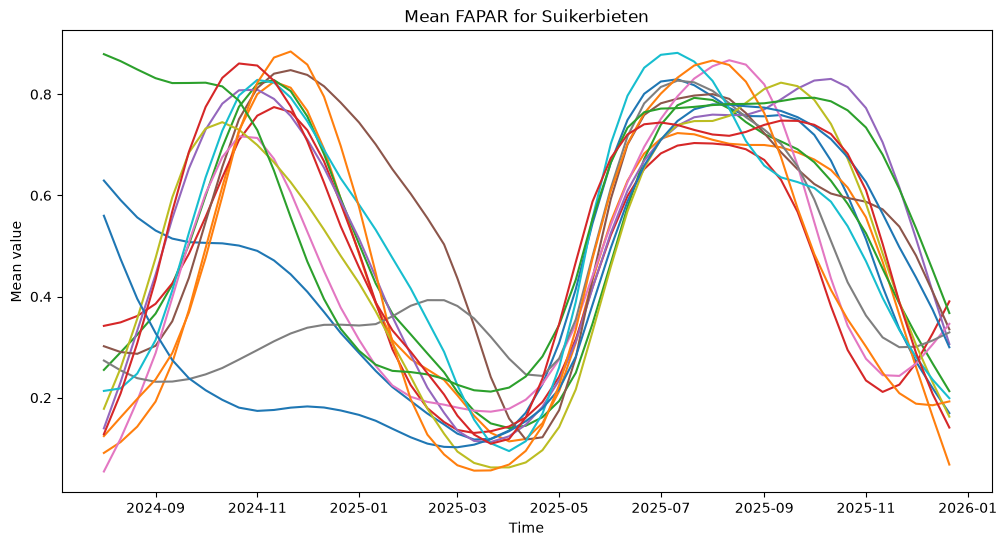

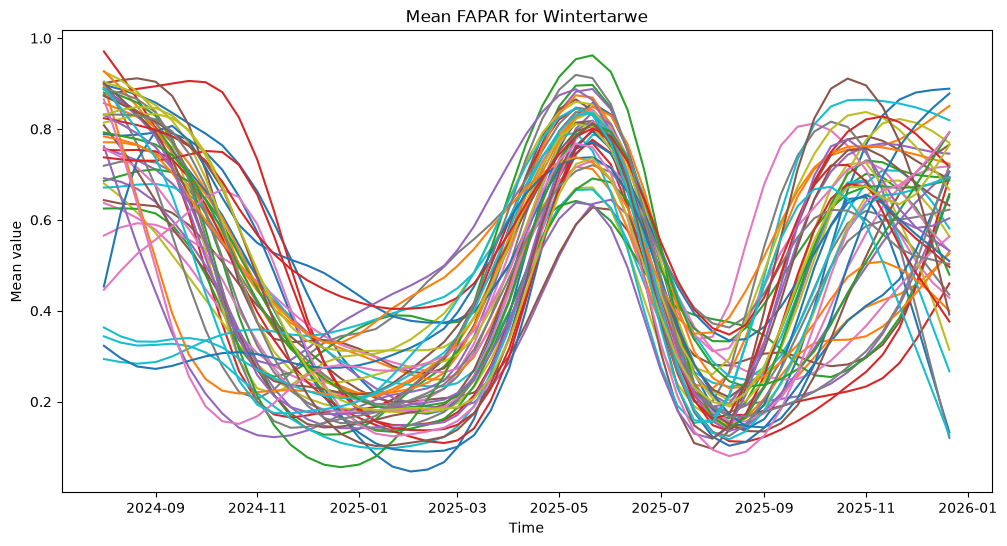

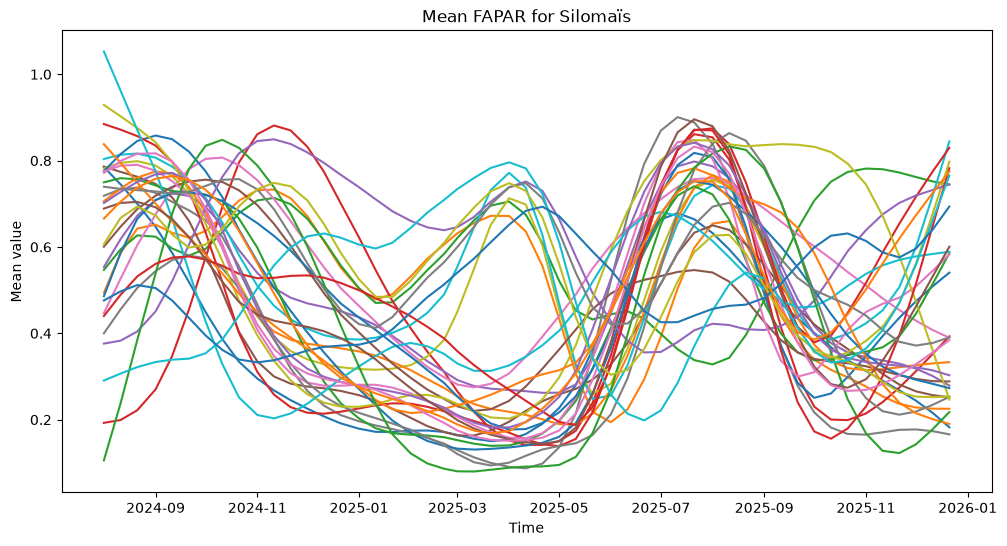

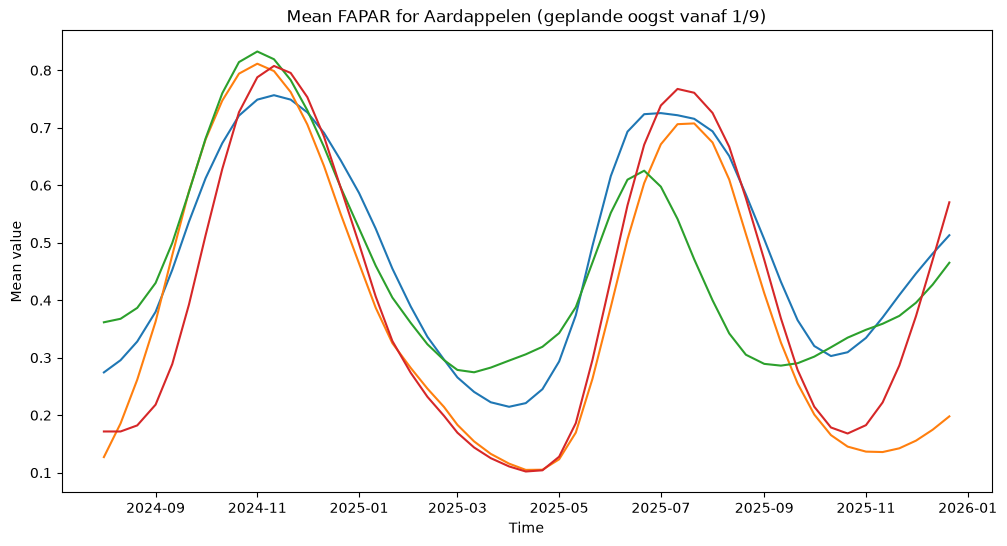

In [14]:
# season 1
data_folder = "smoothed_fapar"
subset_data = subset_fields_2025[['AGPAKEY','MAINCROP']]
plot_fapar_per_crop_type(data_folder, subset_data)

Similarly, the following helper function visualises and compares the smoothed and unsmoothed FAPAR time series for a small number of parcels. The idea for the plot is to confirm the working of the Whittaker smoothing UDF.

In [16]:
def plot_smoothening_effect(pre_data, post_data, subset_data):
    for crop_type in subset_data['MAINCROP'].unique():
        crop_subset = subset_data[subset_data['MAINCROP'] == crop_type]
        #load netcdf data for each crop type
        fig, ax = plt.subplots(figsize=(12, 6))
        netcdf_data = {row['AGPAKEY']: f"{post_data}/openEO_{row['AGPAKEY']}.nc" for index, row in crop_subset.iterrows()}
        i=0
        for index, row in crop_subset.iterrows():

            # Open lazily — does not load the whole file into RAM
            agpakey = row['AGPAKEY']
            ds_pre = xr.open_dataset(f"{pre_data}/openEO_{agpakey}.nc")
            ds_post = xr.open_dataset(f"{post_data}/openEO_{agpakey}.nc")

            # Spatial mean for every timestep
            ts_pre = ds_pre["FAPAR"].mean(dim=["x", "y"])
            ts_post = ds_post["FAPAR"].mean(dim=["x", "y"])

            # Load only the resulting time series
            ts_pre = ts_pre.load()
            ts_post = ts_post.load()

            # Plot
            ax.plot(
                ts_pre["t"],
                ts_pre,
                label=f"{agpakey} (pre)",
                color='gray',
                marker='o', 
            )
            ax.plot(
                ts_post["t"],
                ts_post,
                label=f"{agpakey} (post)",
                color='green'
            )

            ds_pre.close()
            ds_post.close()
            # just plot one for diagnostic purposes
            # break
            i += 1
            if i >= 3:
                break

        ax.set_xlabel("Time")
        ax.set_ylabel("Mean value")
        ax.set_title(f"Smoothing Effect for {crop_type}")
        ax.legend(labels=['Before Smoothing', 'After Smoothing'])
        plt.show()
    

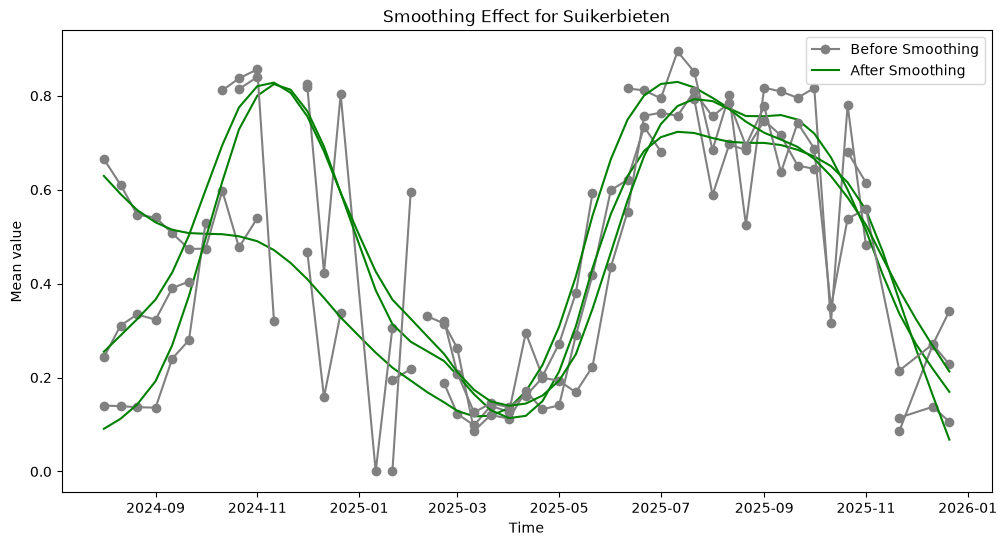

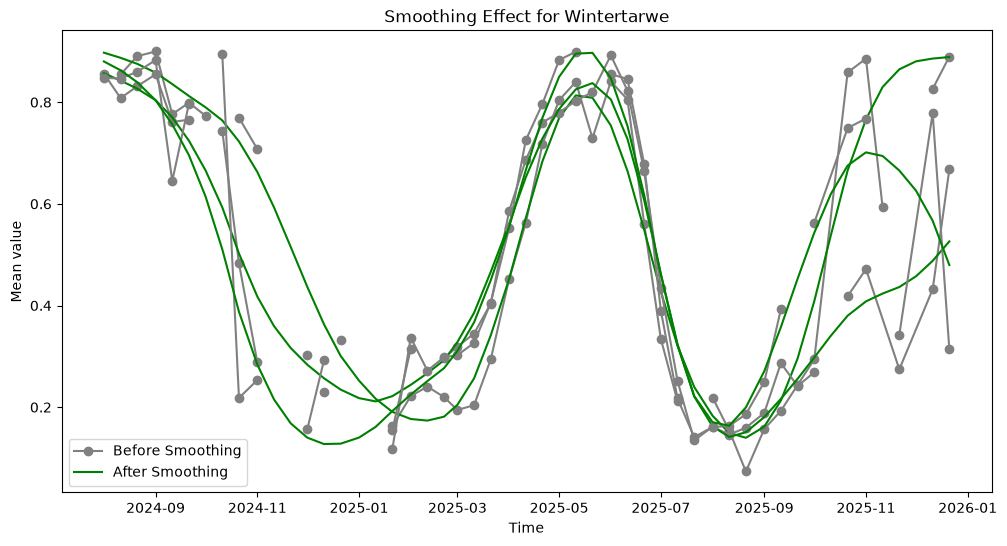

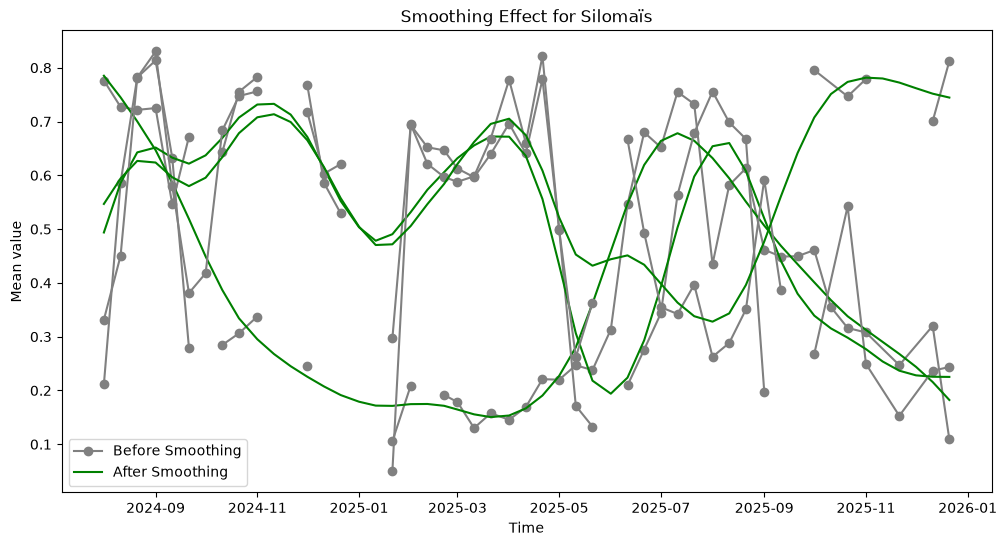

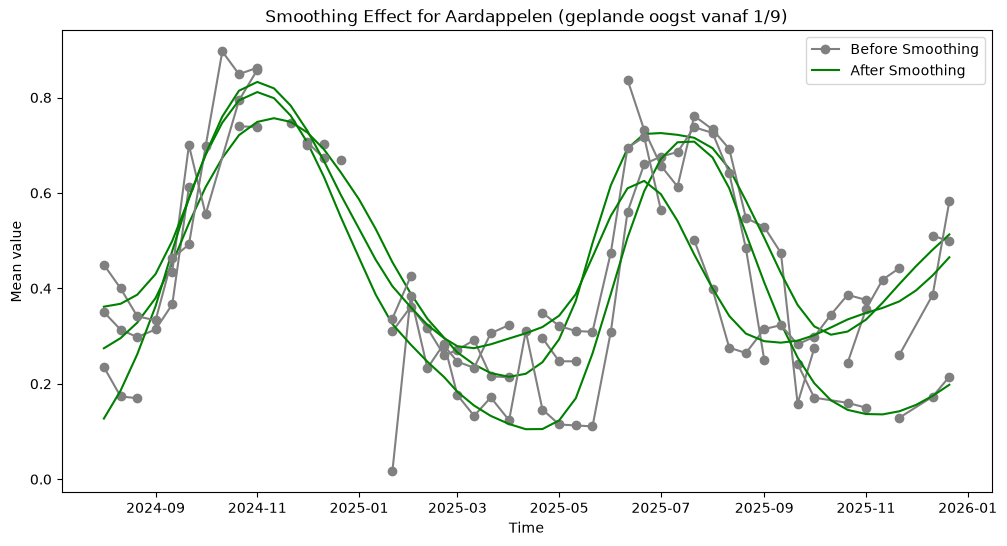

In [19]:
pre_data = "original_fapar"
post_data = "smoothed_fapar"
subset_data = fields_2025[['AGPAKEY','MAINCROP']]
plot_smoothening_effect(pre_data, post_data, subset_data)

To ensure the smoothing is working as intended, we also export quality layers that show the number of valid observations before and after smoothing.

Therefore, in the following cell, we use the `count_time()` function to count the number of images with a valid mask in a time series for all bands of the input dataset. For more details on its implementation, see: https://open-eo.github.io/openeo-python-client/_modules/openeo/rest/datacube.html#DataCube.count_time

Not only do we count the number of valid observations, but we also count the number of time steps evaluated in each case and save them as separate layers. The layers are exported along with the FAPAR results, then converted to percentages and plotted by crop type.

In [20]:
# delineated_map: deaked aggregation not done yet
# smoothed: whittaker smoothing done deaked aggregation not done yet

valid_before = delineated_map.count_time().rename_labels("bands", ["valid_before"])
all_valid_before = delineated_map.apply(lambda x: if_(x.is_nodata(), 0, x))
total_before = all_valid_before.count_time().rename_labels("bands", ["total_before"])

valid_after = smoothed.count_time().rename_labels("bands", ["valid_after"])
all_valid_after = smoothed.apply(lambda x: if_(x.is_nodata(), 0, x))
total_after = all_valid_after.count_time().rename_labels("bands", ["total_after"])

In [21]:
quality_layers = valid_before.merge_cubes(valid_after).merge_cubes(total_before).merge_cubes(total_after)
quality_job = quality_layers.create_job(
    title="Quality Layers",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
quality_job.start_and_wait()

0:00:00 Job 'j-2609061512344aa9bc9f0a408ca74874': send 'start'
0:00:13 Job 'j-2609061512344aa9bc9f0a408ca74874': created (progress 0%)
0:00:18 Job 'j-2609061512344aa9bc9f0a408ca74874': queued (progress 0%)
0:00:25 Job 'j-2609061512344aa9bc9f0a408ca74874': queued (progress 0%)
0:00:33 Job 'j-2609061512344aa9bc9f0a408ca74874': queued (progress 0%)
0:00:43 Job 'j-2609061512344aa9bc9f0a408ca74874': queued (progress 0%)
0:00:55 Job 'j-2609061512344aa9bc9f0a408ca74874': running (progress 6.8%)
0:01:11 Job 'j-2609061512344aa9bc9f0a408ca74874': running (progress 9.0%)
0:01:30 Job 'j-2609061512344aa9bc9f0a408ca74874': running (progress 11.6%)
0:01:54 Job 'j-2609061512344aa9bc9f0a408ca74874': running (progress 14.6%)
0:02:24 Job 'j-2609061512344aa9bc9f0a408ca74874': running (progress 18.1%)
0:03:02 Job 'j-2609061512344aa9bc9f0a408ca74874': running (progress 22.1%)
0:03:50 Job 'j-2609061512344aa9bc9f0a408ca74874': running (progress 26.7%)
0:04:48 Job 'j-2609061512344aa9bc9f0a408ca74874': running 

<BatchJob job_id='j-2609061512344aa9bc9f0a408ca74874'>

In [22]:
result = quality_job.get_results()
result.download_files("quality_layers/")

[WindowsPath('quality_layers/openEO_10260_1152548037.nc'),
 WindowsPath('quality_layers/openEO_10260_1152550158.nc'),
 WindowsPath('quality_layers/openEO_10260_1152577036.nc'),
 WindowsPath('quality_layers/openEO_10260_1211993172.nc'),
 WindowsPath('quality_layers/openEO_10260_1212630039.nc'),
 WindowsPath('quality_layers/openEO_10260_1212632564.nc'),
 WindowsPath('quality_layers/openEO_10260_1245229921.nc'),
 WindowsPath('quality_layers/openEO_10260_1245381178.nc'),
 WindowsPath('quality_layers/openEO_10260_1246397860.nc'),
 WindowsPath('quality_layers/openEO_10260_1246398062.nc'),
 WindowsPath('quality_layers/openEO_10260_1246801725.nc'),
 WindowsPath('quality_layers/openEO_10260_1247870543.nc'),
 WindowsPath('quality_layers/openEO_10260_1248024531.nc'),
 WindowsPath('quality_layers/openEO_10260_1248462041.nc'),
 WindowsPath('quality_layers/openEO_10260_1257280654.nc'),
 WindowsPath('quality_layers/openEO_10260_1257280755.nc'),
 WindowsPath('quality_layers/openEO_10260_1257281361.nc'

In [25]:
def plot_quality_distribution(data_folder, subset_data):
    for crop_type in subset_data['MAINCROP'].unique():
        crop_subset = subset_data[subset_data['MAINCROP'] == crop_type]
        #load netcdf data for each crop type
        fig, ax = plt.subplots(figsize=(12, 6))
        netcdf_data = {row['AGPAKEY']: f"{data_folder}/openEO_{row['AGPAKEY']}.nc" for index, row in crop_subset.iterrows()}
        for agpakey, filepath in netcdf_data.items():
            # Open lazily — does not load the whole file into RAM
            ds = xr.open_dataset(filepath)
            ds['valid_before_percentage'] = ds.valid_before / ds.total_before * 100
            ds['valid_after_percentage'] = ds.valid_after / ds.total_after * 100
            ds_valid = ds[['valid_before_percentage', 'valid_after_percentage']].where(ds[['valid_before_percentage', 'valid_after_percentage']] >= 0)
            plot_data = ds_valid[['valid_before_percentage', 'valid_after_percentage']].to_array().values.reshape(2,-1).swapaxes(0,1)
            
            linestyles = ['-', '--']
            edgecolors = ['b', 'g']
            labels = ['Valid Percentage Before', 'Valid Percentage After']
            ax.hist(plot_data, 
                    fill=False, histtype='bar', linestyle=linestyles,
                    edgecolor=edgecolors, label=labels)
            
            ds.close()

        ax.set_xlabel("Valid Percentage Over Time")
        ax.set_ylabel("# of Pixels")
        ax.legend( labels=labels)
        ax.set_title(f"Quality Distribution for {crop_type}")
        plt.show()

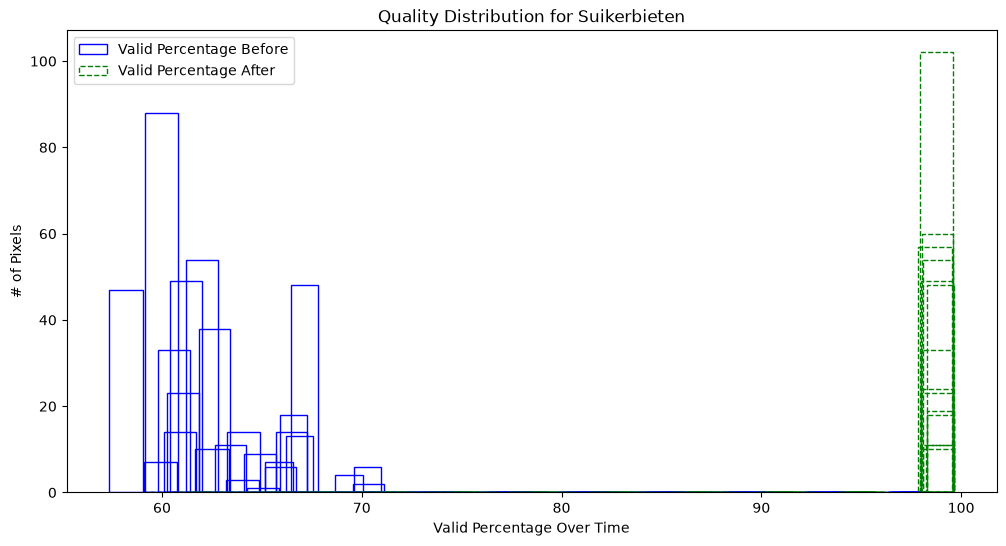

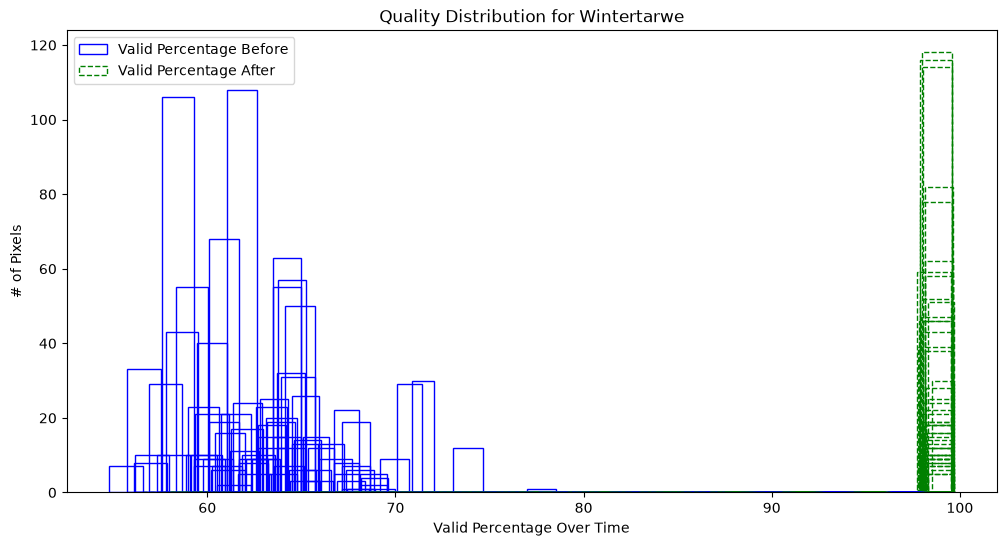

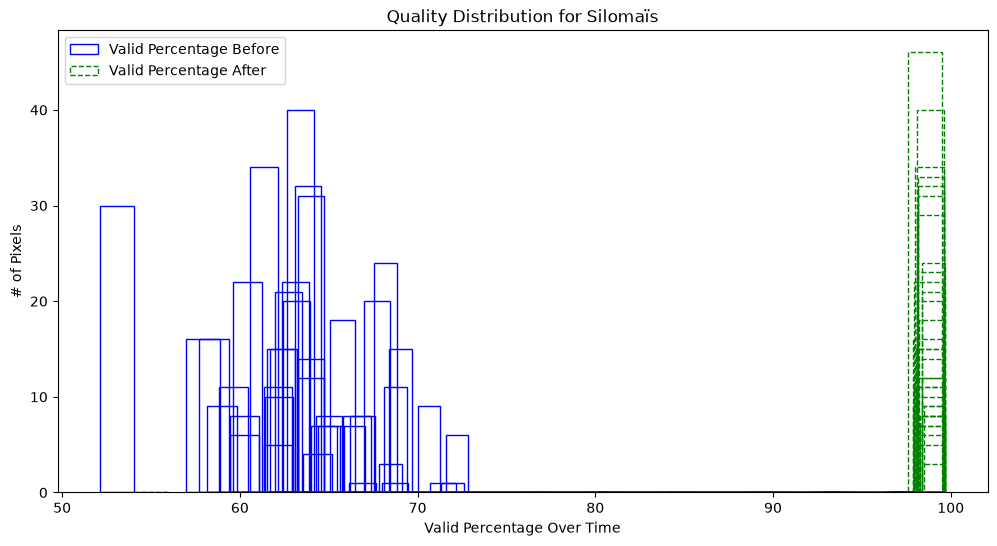

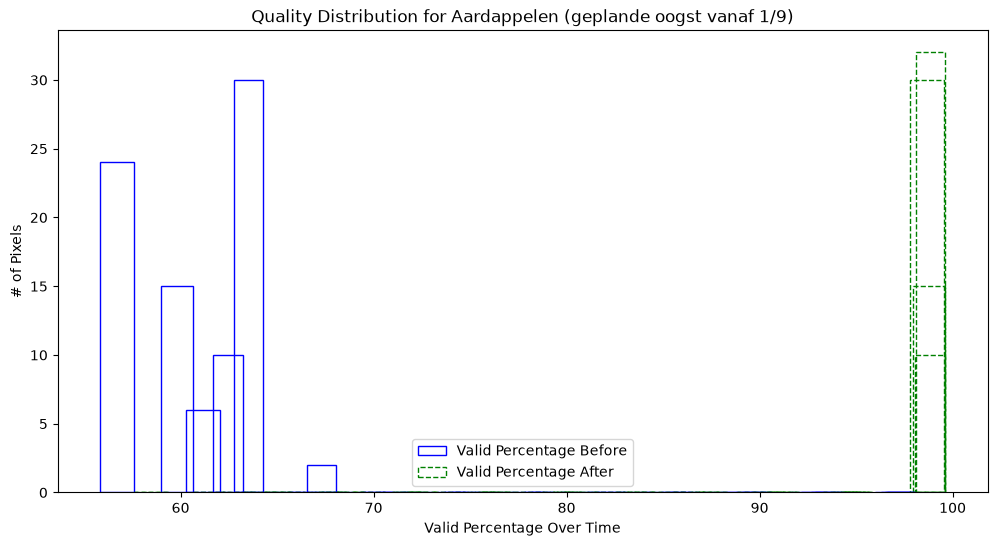

In [26]:
data_folder = "quality_layers"
subset_data = subset_fields_2025[['AGPAKEY','MAINCROP']]
plot_quality_distribution(data_folder, subset_data)

## Season 2: August 2025 to August 2026
Season 2 repeats the workflow for the 2025 season to 2026. Using the same collection, scaling, parcel delineation, smoothing parameters, and dekadal aggregation provides results that can be compared directly with Season 1.

The section exports three complementary outputs for the 2026 parcel layer: unsmoothed dekadal FAPAR (`original_fapar_2026`), smoothed dekadal FAPAR (`smoothed_fapar_2026`), and valid-observation quality layers (`quality_layers_2026`). The repeated workflow demonstrates that the approach is reusable across seasons rather than tailored to one period.

In [27]:
# aggregate to dekad to check the data before smoothing
delineated_map_2026 = delinated_fapar(season2, subset_fields_2026)

without_smoothing_2026 = delineated_map_2026.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job_nosmooth_2026 = without_smoothing_2026.create_job(
    title="100 fields without smoothing (season 2)",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job_nosmooth_2026.start_and_wait()


0:00:00 Job 'j-2609061554244397ba52be3b16ebeb68': send 'start'
0:00:14 Job 'j-2609061554244397ba52be3b16ebeb68': created (progress 0%)
0:00:20 Job 'j-2609061554244397ba52be3b16ebeb68': queued (progress 0%)
0:00:26 Job 'j-2609061554244397ba52be3b16ebeb68': queued (progress 0%)
0:00:34 Job 'j-2609061554244397ba52be3b16ebeb68': queued (progress 0%)
0:00:44 Job 'j-2609061554244397ba52be3b16ebeb68': queued (progress 0%)
0:00:57 Job 'j-2609061554244397ba52be3b16ebeb68': running (progress 6.9%)
0:01:12 Job 'j-2609061554244397ba52be3b16ebeb68': running (progress 9.1%)
0:01:32 Job 'j-2609061554244397ba52be3b16ebeb68': running (progress 11.7%)
0:01:56 Job 'j-2609061554244397ba52be3b16ebeb68': running (progress 14.7%)
0:02:26 Job 'j-2609061554244397ba52be3b16ebeb68': running (progress 18.2%)
0:03:04 Job 'j-2609061554244397ba52be3b16ebeb68': running (progress 22.2%)
0:03:51 Job 'j-2609061554244397ba52be3b16ebeb68': running (progress 26.7%)
0:04:49 Job 'j-2609061554244397ba52be3b16ebeb68': running 

<BatchJob job_id='j-2609061554244397ba52be3b16ebeb68'>

In [28]:
result = deked_job_nosmooth_2026.get_results()
result.download_files("original_fapar_2026/")

[WindowsPath('original_fapar_2026/openEO_10262_1152550158.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1211993172.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1212630039.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1245381178.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1246799806.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1247739086.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1247870543.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1248024531.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1248462041.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1248462142.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1257278836.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1257287728.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1257420696.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1257456668.nc'),
 WindowsPath('original_fapar_2026/openEO_10262_1257457072.nc'),
 WindowsPath('original_fapar_2026/openEO

In [29]:
# apply Whittaker smoothing UDF along the temporal dimension
smoothed_2026 = delineated_map_2026.apply_dimension(
    process=openeo.UDF.from_file("whittaker_udf.py"),
    dimension="t",
    context={"smoothing_lambda":10000, "prediction_period": 2},
)

# aggregate deaked after whittaker
smoothed_dekad_2026 = smoothed_2026.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job_2026 = smoothed_dekad_2026.create_job(
    title="100 fields with Whittaker smoothing",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job_2026.start_and_wait()


0:00:00 Job 'j-2609061602084b34b16d455d598a3bf4': send 'start'
0:00:12 Job 'j-2609061602084b34b16d455d598a3bf4': created (progress 0%)
0:00:17 Job 'j-2609061602084b34b16d455d598a3bf4': queued (progress 0%)
0:00:24 Job 'j-2609061602084b34b16d455d598a3bf4': queued (progress 0%)
0:00:32 Job 'j-2609061602084b34b16d455d598a3bf4': queued (progress 0%)
0:00:42 Job 'j-2609061602084b34b16d455d598a3bf4': running (progress 5.0%)
0:00:55 Job 'j-2609061602084b34b16d455d598a3bf4': running (progress 6.8%)
0:01:10 Job 'j-2609061602084b34b16d455d598a3bf4': running (progress 9.0%)
0:01:30 Job 'j-2609061602084b34b16d455d598a3bf4': running (progress 11.6%)
0:01:54 Job 'j-2609061602084b34b16d455d598a3bf4': running (progress 14.7%)
0:02:24 Job 'j-2609061602084b34b16d455d598a3bf4': running (progress 18.2%)
0:03:02 Job 'j-2609061602084b34b16d455d598a3bf4': running (progress 22.2%)
0:03:48 Job 'j-2609061602084b34b16d455d598a3bf4': running (progress 26.6%)
0:04:47 Job 'j-2609061602084b34b16d455d598a3bf4': runni

<BatchJob job_id='j-2609061602084b34b16d455d598a3bf4'>

In [30]:
result = deked_job_2026.get_results()
result.download_files("smoothed_fapar_2026/")

[WindowsPath('smoothed_fapar_2026/openEO_10262_1152550158.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1211993172.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1212630039.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1245381178.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1246799806.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1247739086.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1247870543.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1248024531.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1248462041.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1248462142.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1257278836.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1257287728.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1257420696.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1257456668.nc'),
 WindowsPath('smoothed_fapar_2026/openEO_10262_1257457072.nc'),
 WindowsPath('smoothed_fapar_2026/openEO

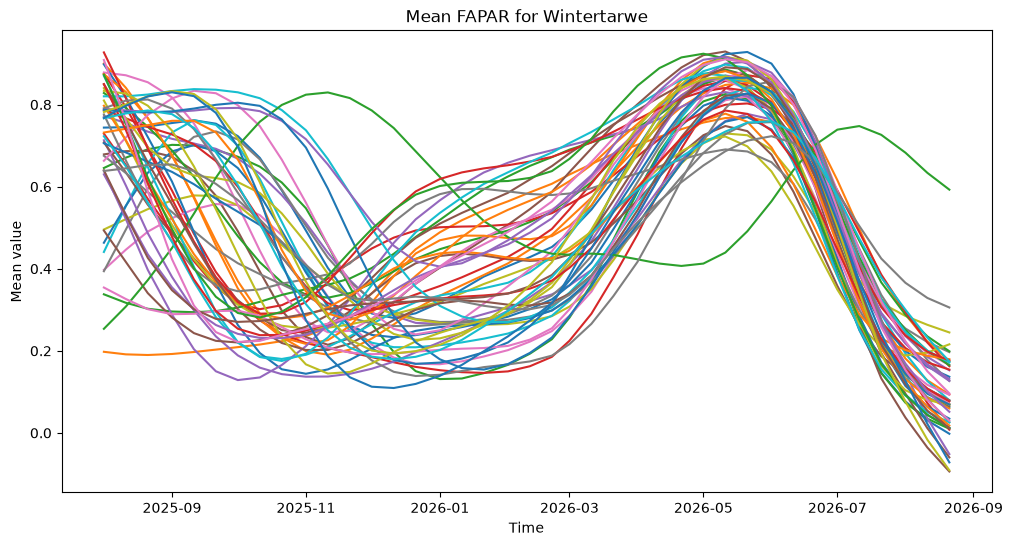

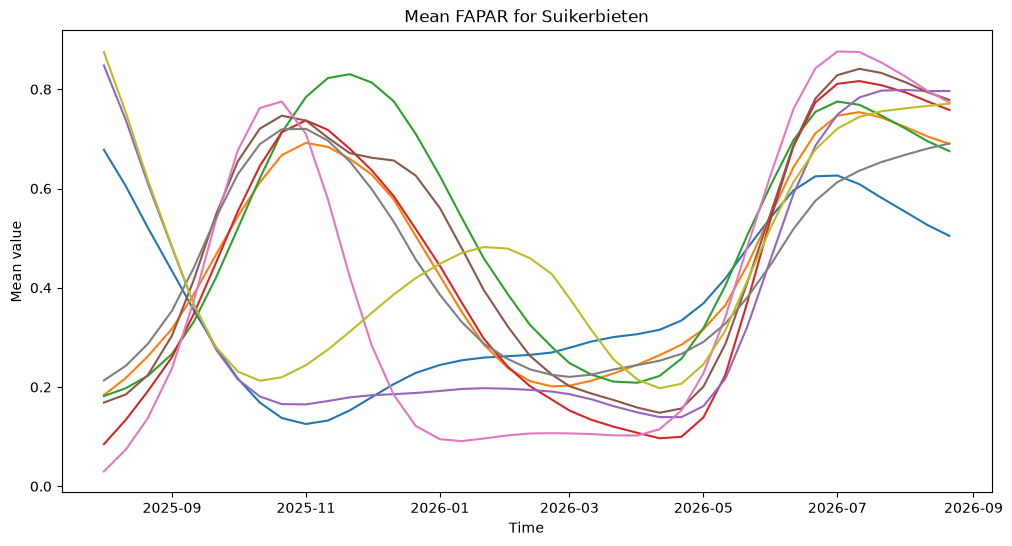

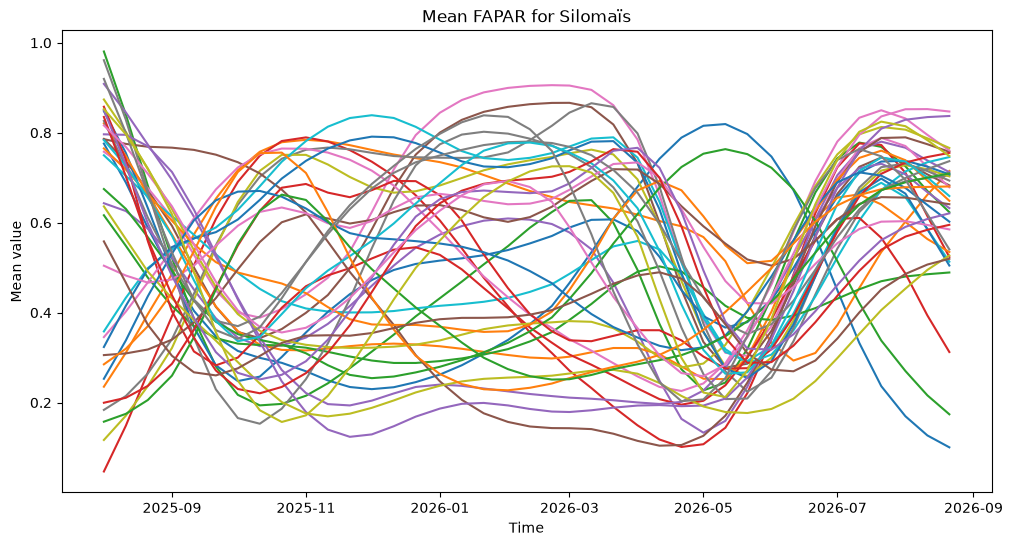

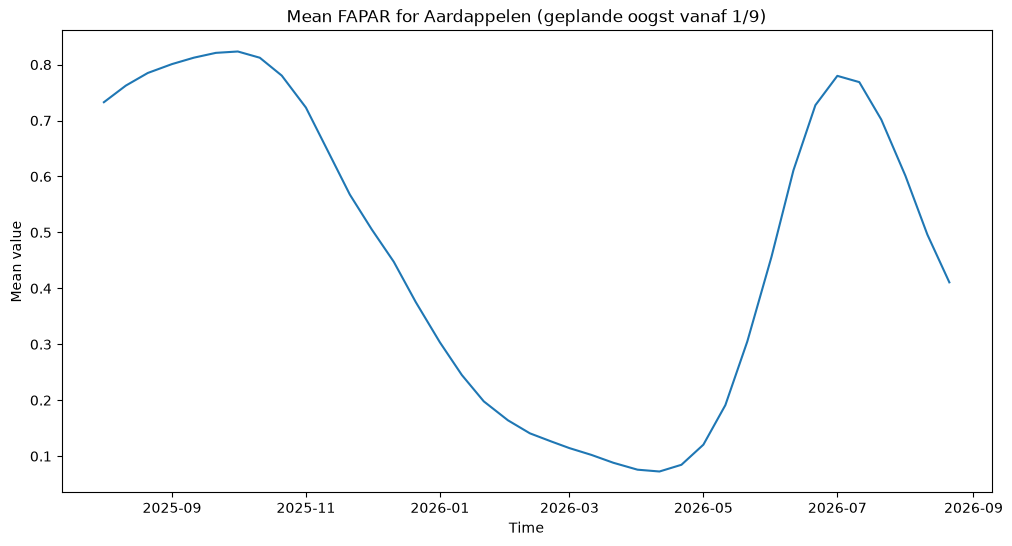

In [31]:
# season 2
data_folder = "smoothed_fapar_2026"
subset_data = subset_fields_2026[['AGPAKEY','MAINCROP']]
plot_fapar_per_crop_type(data_folder, subset_data)

In [40]:
# delineated_map_2026: deaked aggregation not done yet
# smoothed: whittaker smoothing done deaked aggregation not done yet

valid_before_2026 = delineated_map_2026.count_time().rename_labels("bands", ["valid_before"])
all_valid_before_2026 = delineated_map_2026.apply(lambda x: if_(x.is_nodata(), 0, x))
total_before_2026 = all_valid_before_2026.count_time().rename_labels("bands", ["total_before"])

valid_after_2026 = smoothed_2026.count_time().rename_labels("bands", ["valid_after"])
all_valid_after_2026 = smoothed_2026.apply(lambda x: if_(x.is_nodata(), 0, x))
total_after_2026 = all_valid_after_2026.count_time().rename_labels("bands", ["total_after"])

In [41]:
quality_layers_2026 = valid_before_2026.merge_cubes(valid_after_2026).merge_cubes(total_before_2026).merge_cubes(total_after_2026)
quality_job_2026 = quality_layers_2026.create_job(
    title="Quality Layers (Season 2)",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
quality_job_2026.start_and_wait()

0:00:00 Job 'j-2609061651524bcf9e702926b88dc9a9': send 'start'
0:00:16 Job 'j-2609061651524bcf9e702926b88dc9a9': queued (progress 0%)
0:00:21 Job 'j-2609061651524bcf9e702926b88dc9a9': queued (progress 0%)
0:00:28 Job 'j-2609061651524bcf9e702926b88dc9a9': queued (progress 0%)
0:00:36 Job 'j-2609061651524bcf9e702926b88dc9a9': queued (progress 0%)
0:00:46 Job 'j-2609061651524bcf9e702926b88dc9a9': queued (progress 0%)
0:00:58 Job 'j-2609061651524bcf9e702926b88dc9a9': running (progress 6.9%)
0:01:14 Job 'j-2609061651524bcf9e702926b88dc9a9': running (progress 9.1%)
0:01:33 Job 'j-2609061651524bcf9e702926b88dc9a9': running (progress 11.7%)
0:01:57 Job 'j-2609061651524bcf9e702926b88dc9a9': running (progress 14.7%)
0:02:27 Job 'j-2609061651524bcf9e702926b88dc9a9': running (progress 18.2%)
0:03:05 Job 'j-2609061651524bcf9e702926b88dc9a9': running (progress 22.2%)
0:03:52 Job 'j-2609061651524bcf9e702926b88dc9a9': running (progress 26.6%)
0:04:50 Job 'j-2609061651524bcf9e702926b88dc9a9': running (

<BatchJob job_id='j-2609061651524bcf9e702926b88dc9a9'>

In [42]:
result_2026 = quality_job_2026.get_results()
result_2026.download_files("quality_layers_2026/")

[WindowsPath('quality_layers_2026/openEO_10262_1152550158.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1211993172.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1212630039.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1245381178.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1246799806.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1247739086.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1247870543.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1248024531.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1248462041.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1248462142.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1257278836.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1257287728.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1257420696.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1257456668.nc'),
 WindowsPath('quality_layers_2026/openEO_10262_1257457072.nc'),
 WindowsPath('quality_layers_2026/openEO

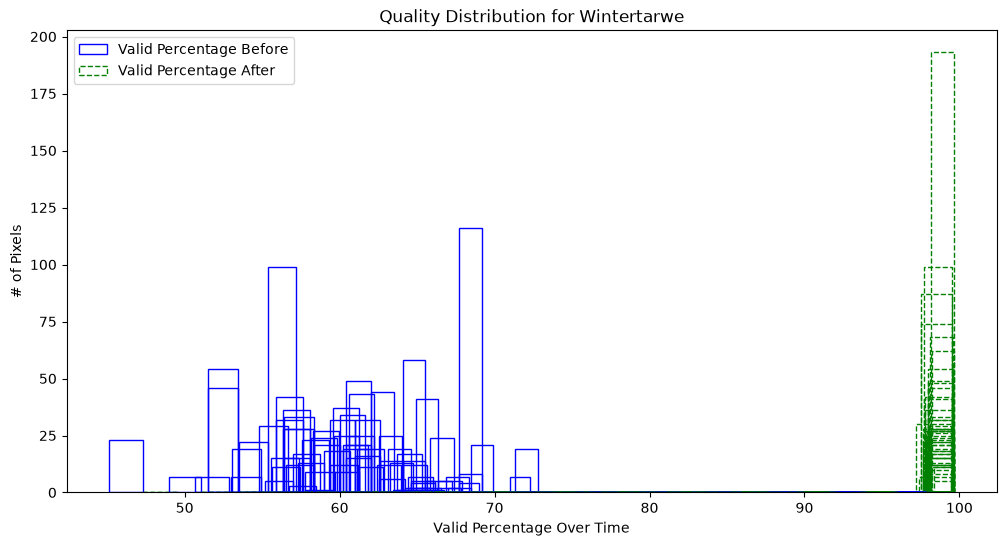

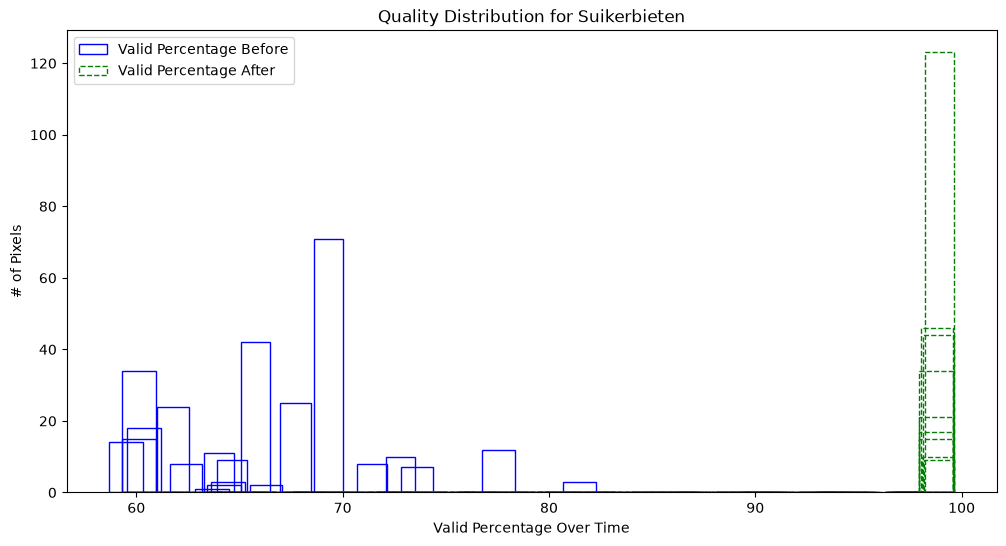

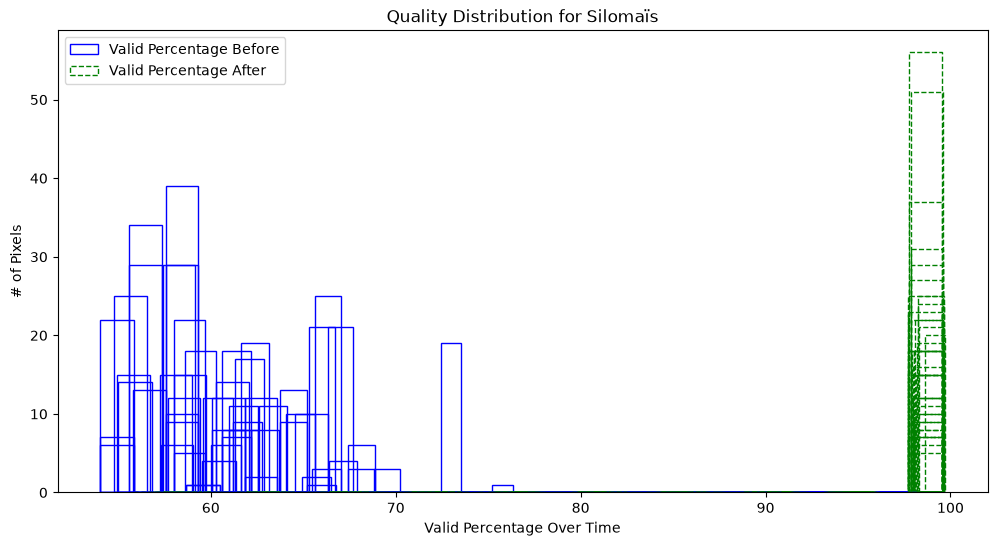

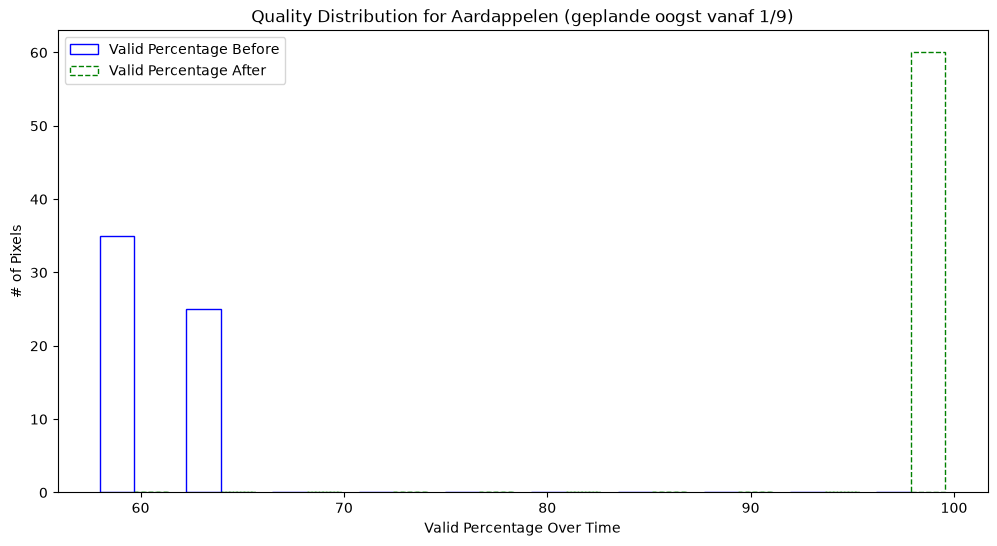

In [43]:
data_folder = "quality_layers_2026"
subset_data = subset_fields_2026[['AGPAKEY','MAINCROP']]
plot_quality_distribution(data_folder, subset_data)